In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [23]:
data = pd.read_csv('./1/2026021218.csv', index_col = 'length')
data.columns = pd.to_datetime(
    data.columns
      .str.replace("results_", "", regex=False)
      .str.replace("_dts", "", regex=False),
    format="%Y_%m_%d%H_%M_%S",
)
data.columns = data.columns.strftime("%H:%M:%S")


In [24]:
data.head(5)

,18:00:02,18:00:12,18:00:22,18:00:32,18:00:42,18:00:52,18:01:02,18:01:12,18:01:22,18:01:32,...,18:58:24,18:58:34,18:58:44,18:58:54,18:59:04,18:59:14,18:59:24,18:59:34,18:59:45,18:59:55
length,,,,,,,,,,,,,,,,,,,,,
0,24.4835,23.2147,22.4705,21.7309,21.4533,21.8424,23.5421,22.6928,24.2231,24.3462,...,26.9861,26.9887,17.1119,21.3883,25.2968,21.3936,22.3795,26.0739,15.5371,22.7211
1,24.9495,23.0451,23.1000,23.9291,23.1316,23.0125,24.1044,22.9832,22.0201,22.9440,...,24.2888,26.1167,24.9086,29.0581,19.8445,23.4161,24.0183,20.9696,22.4713,23.5858
2,24.8031,23.8566,23.0522,24.0229,23.1688,23.7714,24.1873,24.9918,23.9746,22.8745,...,22.9916,24.4438,22.1649,22.2202,28.7777,24.3956,20.4597,24.4130,23.9805,19.5486
3,24.8990,23.5244,23.5220,24.1774,25.2010,23.6105,24.3487,24.5379,23.7203,22.7274,...,17.4119,25.9830,24.9591,26.4024,32.4964,20.9309,24.7570,25.1425,15.8464,26.8547
4,23.7928,22.3595,23.1030,23.7548,23.0744,21.5793,23.8925,24.0615,22.5755,22.0793,...,23.3268,25.1935,23.9553,22.4051,21.4742,21.2554,17.5839,29.5709,24.7058,21.5101


In [25]:
data.head(10)

,18:00:02,18:00:12,18:00:22,18:00:32,18:00:42,18:00:52,18:01:02,18:01:12,18:01:22,18:01:32,...,18:58:24,18:58:34,18:58:44,18:58:54,18:59:04,18:59:14,18:59:24,18:59:34,18:59:45,18:59:55
length,,,,,,,,,,,,,,,,,,,,,
0,24.483500,23.21470,22.470500,21.73090,21.453300,21.84240,23.54210,22.692800,24.223100,24.346200,...,26.98610,26.98870,17.11190,21.38830,25.296800,21.39360,22.379500,26.07390,15.537100,22.72110
1,24.949500,23.04510,23.100000,23.92910,23.131600,23.01250,24.10440,22.983200,22.020100,22.944000,...,24.28880,26.11670,24.90860,29.05810,19.844500,23.41610,24.018300,20.96960,22.471300,23.58580
2,24.803100,23.85660,23.052200,24.02290,23.168800,23.77140,24.18730,24.991800,23.974600,22.874500,...,22.99160,24.44380,22.16490,22.22020,28.777700,24.39560,20.459700,24.41300,23.980500,19.54860
3,24.899000,23.52440,23.522000,24.17740,25.201000,23.61050,24.34870,24.537900,23.720300,22.727400,...,17.41190,25.98300,24.95910,26.40240,32.496400,20.93090,24.757000,25.14250,15.846400,26.85470
4,23.792800,22.35950,23.103000,23.75480,23.074400,21.57930,23.89250,24.061500,22.575500,22.079300,...,23.32680,25.19350,23.95530,22.40510,21.474200,21.25540,17.583900,29.57090,24.705800,21.51010
5,20.103400,19.51770,20.384800,20.99170,20.084600,19.51030,20.39670,20.342900,20.686300,19.352800,...,17.29960,24.33090,25.66750,22.67700,20.033600,16.31330,20.667500,24.97070,13.127200,25.00710
6,7.095380,6.10567,7.030980,6.79918,7.275600,6.04549,6.96414,6.502980,6.153780,7.176370,...,3.27714,3.74599,8.46482,9.79858,9.708330,12.49220,3.030850,12.80210,8.648100,7.14108
7,-0.745371,-1.97284,-0.742297,-1.38578,0.810242,-1.41351,-1.00905,-0.522384,0.648042,0.340192,...,-1.74571,2.46597,4.00532,4.64952,-3.606990,5.87851,-0.421989,3.46853,-0.713797,4.74734
8,-3.573680,-4.13937,-2.800270,-4.01796,-2.943900,-2.96868,-3.97675,-3.982010,-3.898150,-4.775830,...,-1.75562,-1.35334,-1.20012,-1.85746,-3.593410,1.24672,-4.023810,-2.11973,-1.325780,-1.57029


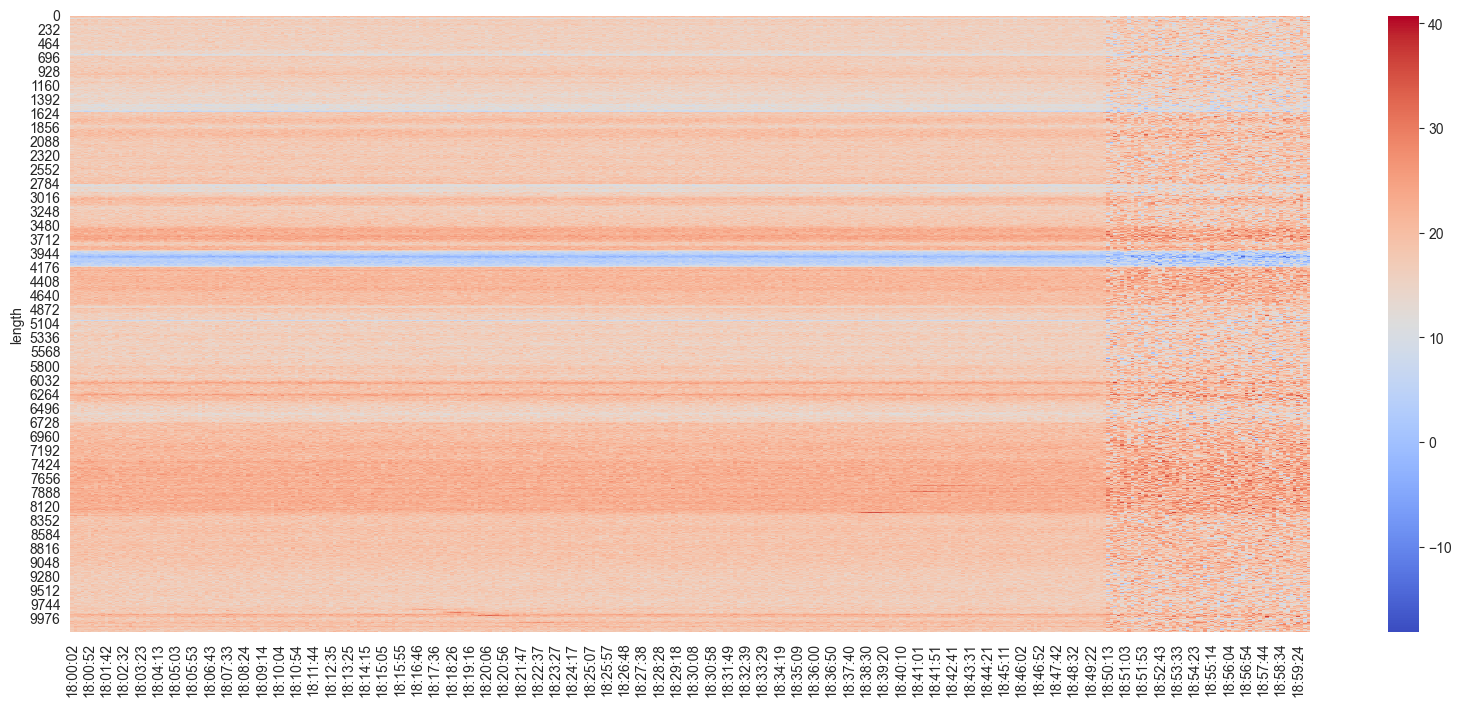

In [26]:
plt.figure(figsize = (20,8))
ax = sns.heatmap(data, cmap='coolwarm')
ax.figure.savefig("./pictures/общая_тепловая_карта.png", dpi=200, bbox_inches="tight")
plt.show()

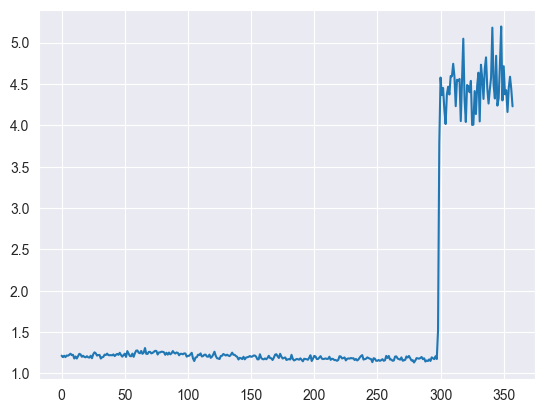

In [27]:
#Убираем шумную часть в отдельный датасет
times = data.columns

T = data.to_numpy()
change_per_frame = np.median(
    np.abs(np.diff(T, axis=1)), axis=0
)
ax = sns.lineplot(change_per_frame)
ax.figure.savefig("./pictures/median_diff_temp_trough_leght", dpi=200, bbox_inches="tight")


In [28]:
median_diff = np.median(change_per_frame)
change_idx = np.flatnonzero(change_per_frame > median_diff + 0.5)[0]
change_idx

np.int64(299)

In [29]:
broken = data.iloc[:,change_idx: ]
normal = data.iloc[:,:change_idx ]

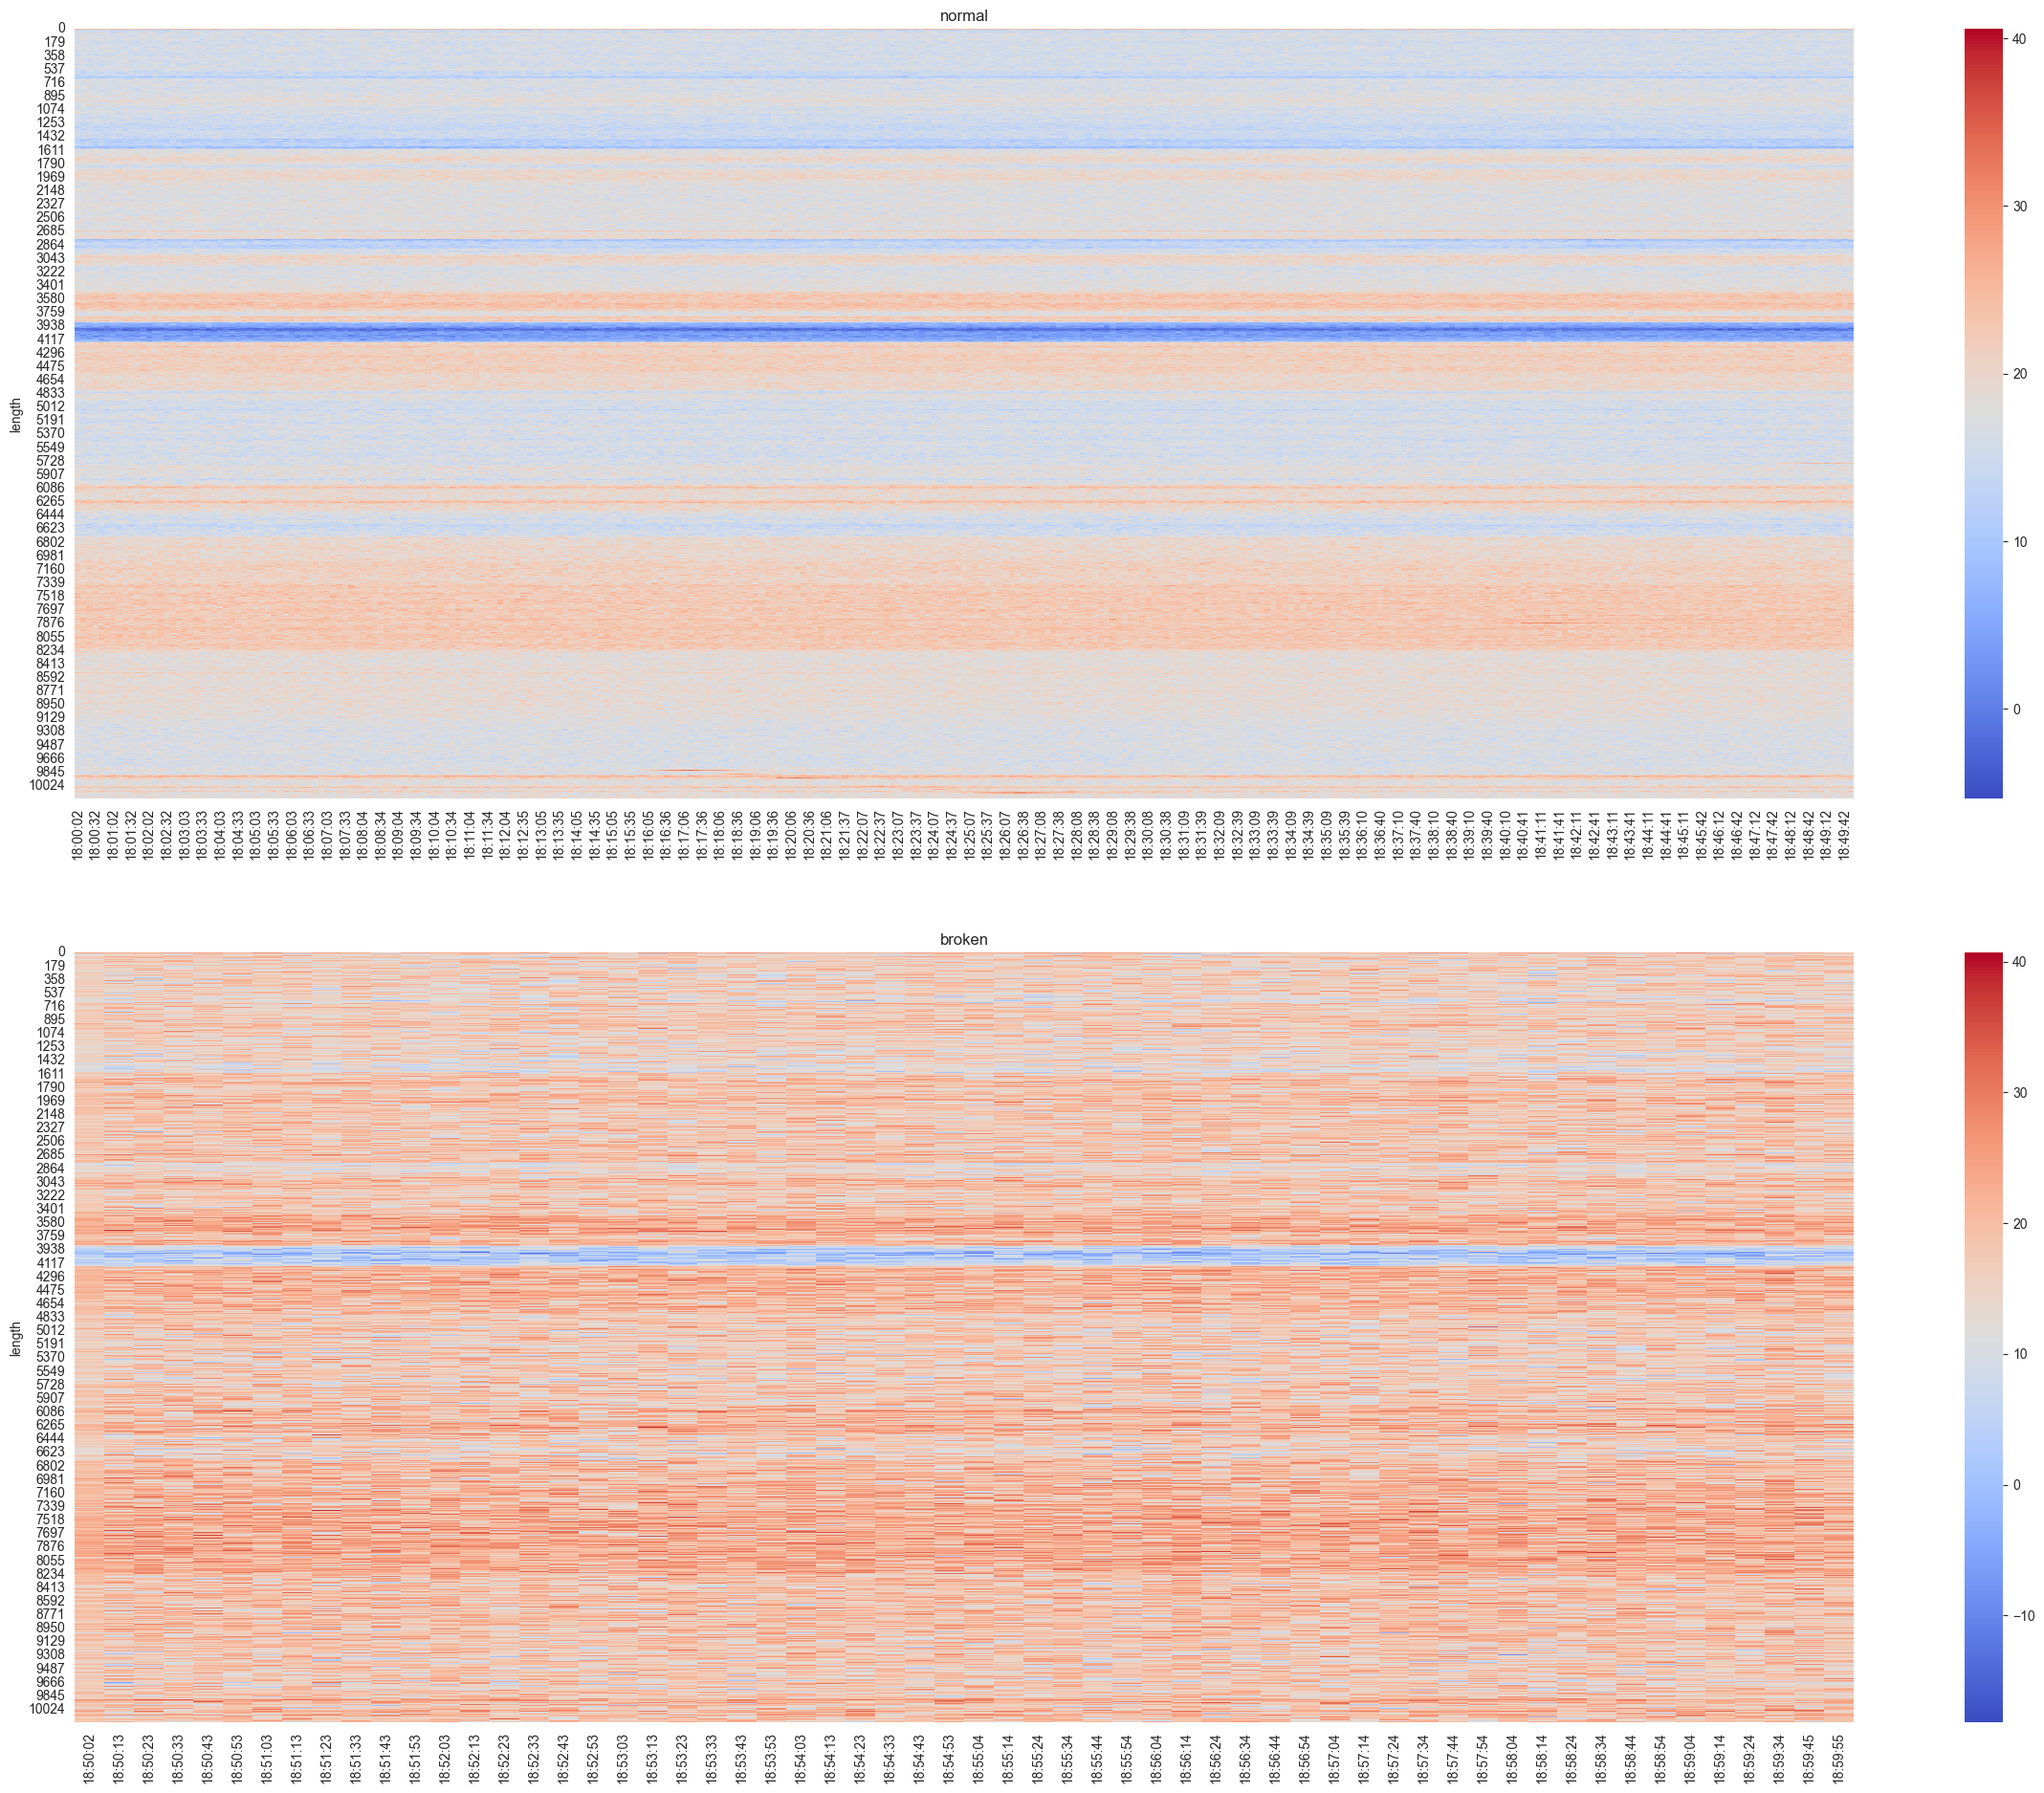

In [30]:
fig, ax = plt.subplots(2, 1, figsize = (30,23))
sns.heatmap(broken, cmap='coolwarm', ax=ax[1])
sns.heatmap(normal, cmap='coolwarm', ax=ax[0])
ax[0].set_title('normal')
ax[1].set_title('broken')
fig.savefig("./pictures/нормальное_против_плохое.png", dpi=200, bbox_inches="tight")


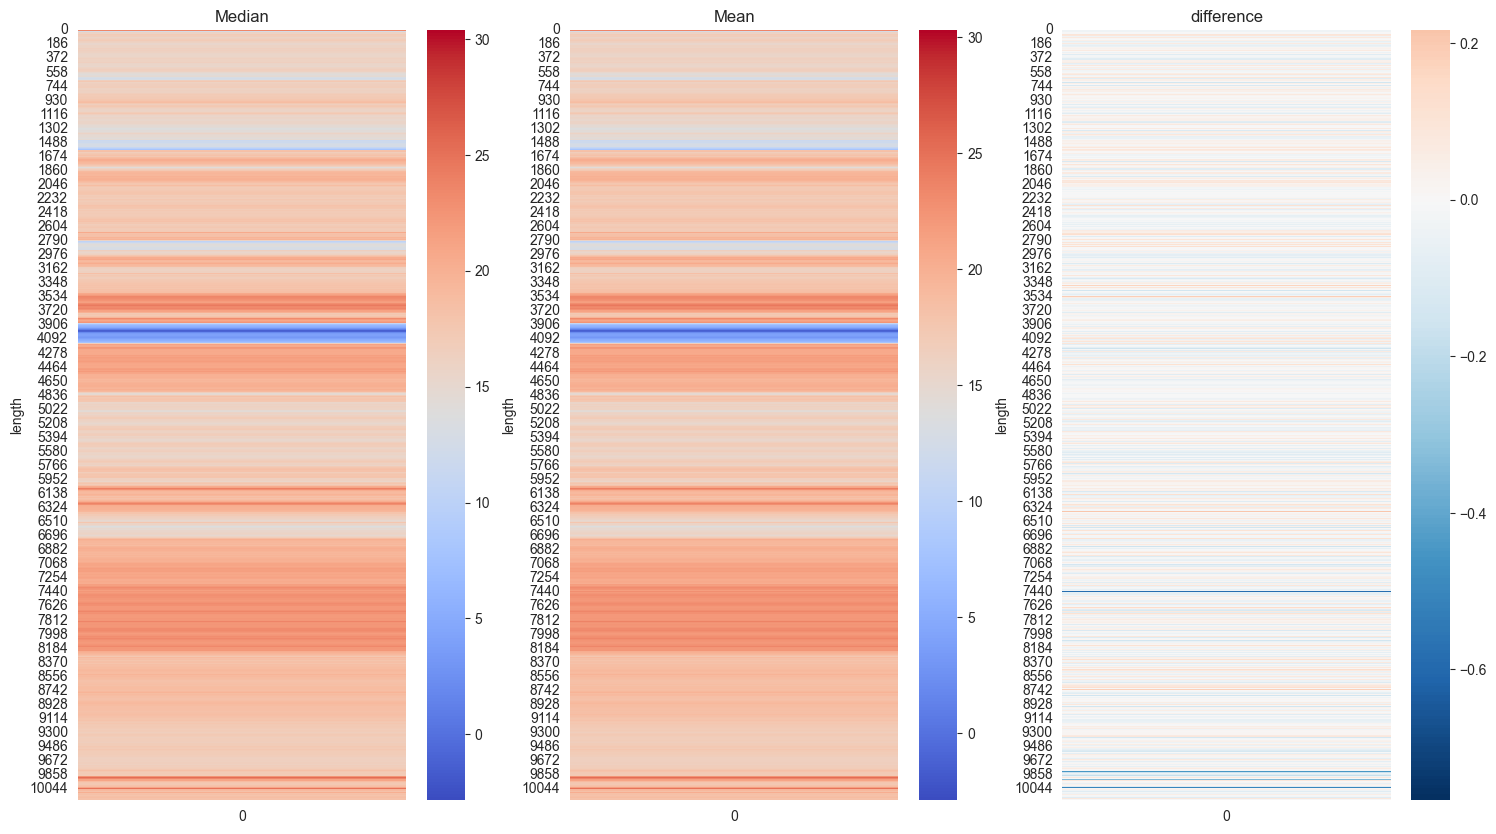

In [31]:
df_median = normal.median(axis=1).to_frame()
df_mean = normal.mean(axis=1).to_frame()

fig, ax = plt.subplots(1, 3, figsize=(18,10))
sns.heatmap(df_median, cmap='coolwarm', ax=ax[0])
sns.heatmap(df_mean, cmap='coolwarm', ax=ax[1])
sns.heatmap(df_median - df_mean,cmap = 'RdBu_r', center = 0, ax=ax[2])
ax[0].set_title('Median')
ax[1].set_title('Mean')
ax[2].set_title('difference')

fig.savefig("./pictures/median_mean_diff.png", dpi=200, bbox_inches="tight")

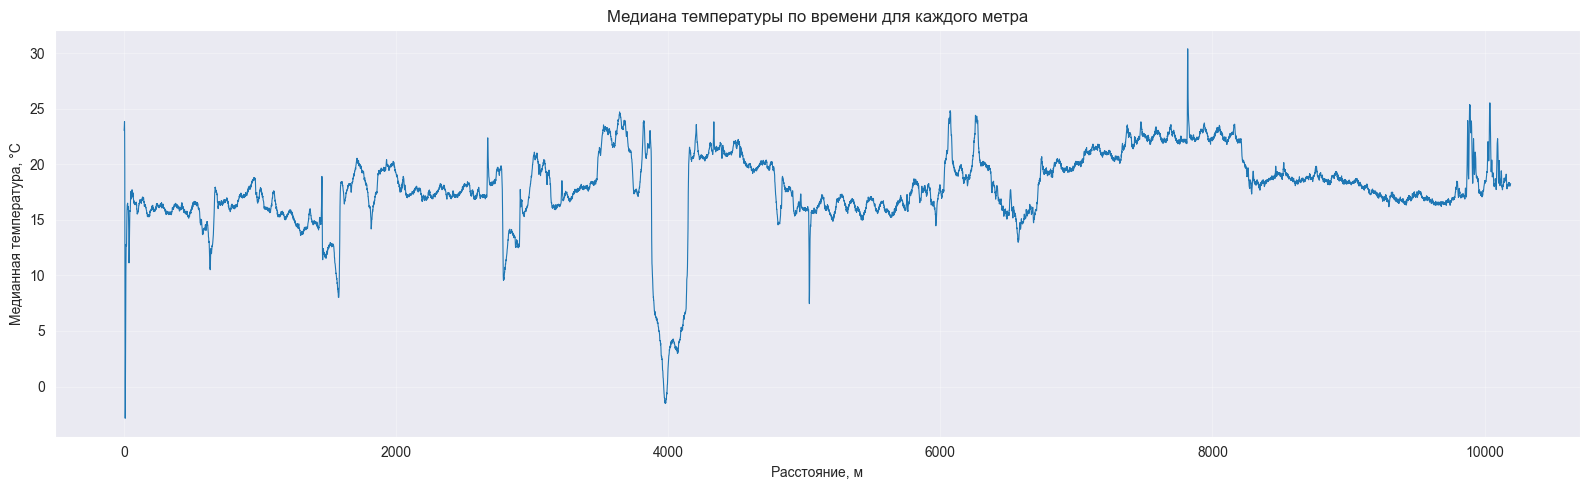

In [35]:
median_per_meter = normal.median(axis=1).sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(median_per_meter.index, median_per_meter.values, linewidth=0.8)

ax.set_xlabel("Расстояние, м")
ax.set_ylabel("Медианная температура, °C")
ax.set_title("Медиана температуры по времени для каждого метра")
ax.grid(alpha=0.3)
fig.savefig("./pictures/Медиана_температуры_по_времени_для_каждого_метра.png", dpi=200, bbox_inches="tight")

plt.tight_layout()

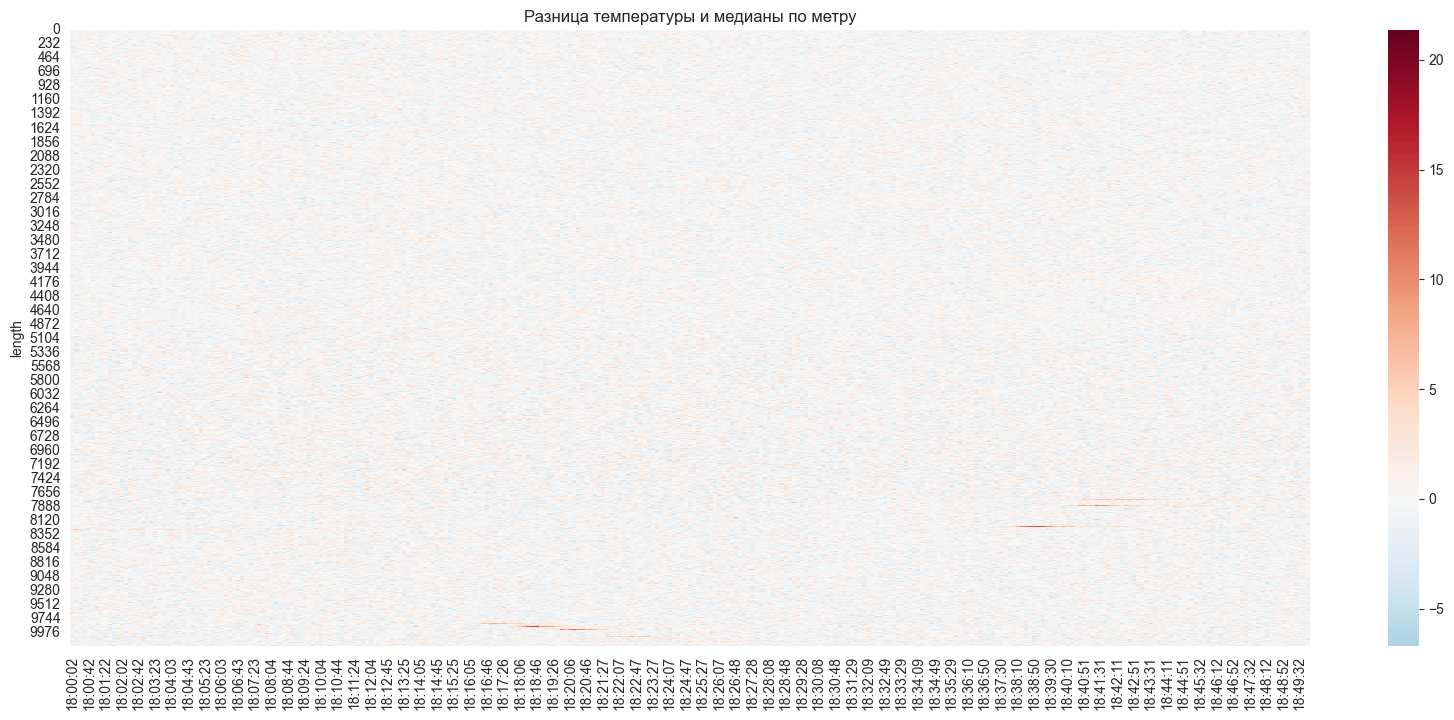

In [33]:
median_per_meter = normal.median(axis=1)
residual = normal.sub(median_per_meter, axis=0)
plt.figure(figsize = (20,8))
ax = sns.heatmap(residual, cmap='RdBu_r', center = 0)
ax.set_title('Разница температуры и медианы по метру')
ax.figure.savefig("./pictures/разница_температуры_и_медианы.png", dpi=200, bbox_inches="tight")


In [54]:
dt = pd.to_datetime(residual.columns, format='%H:%M:%S')

train = dt < '1900-01-01 18:15:00'
val = (dt >= '1900-01-01 18:15:00') & (dt < '1900-01-01 18:30:00')
test = dt >= '1900-01-01 18:30:00'

print(train.sum(), val.sum(), test.sum())

train_data = residual.loc[:, train].copy()
val_data = residual.loc[:, val].copy()
test_data = residual.loc[:, test].copy()

90 90 119


<Axes: ylabel='length'>

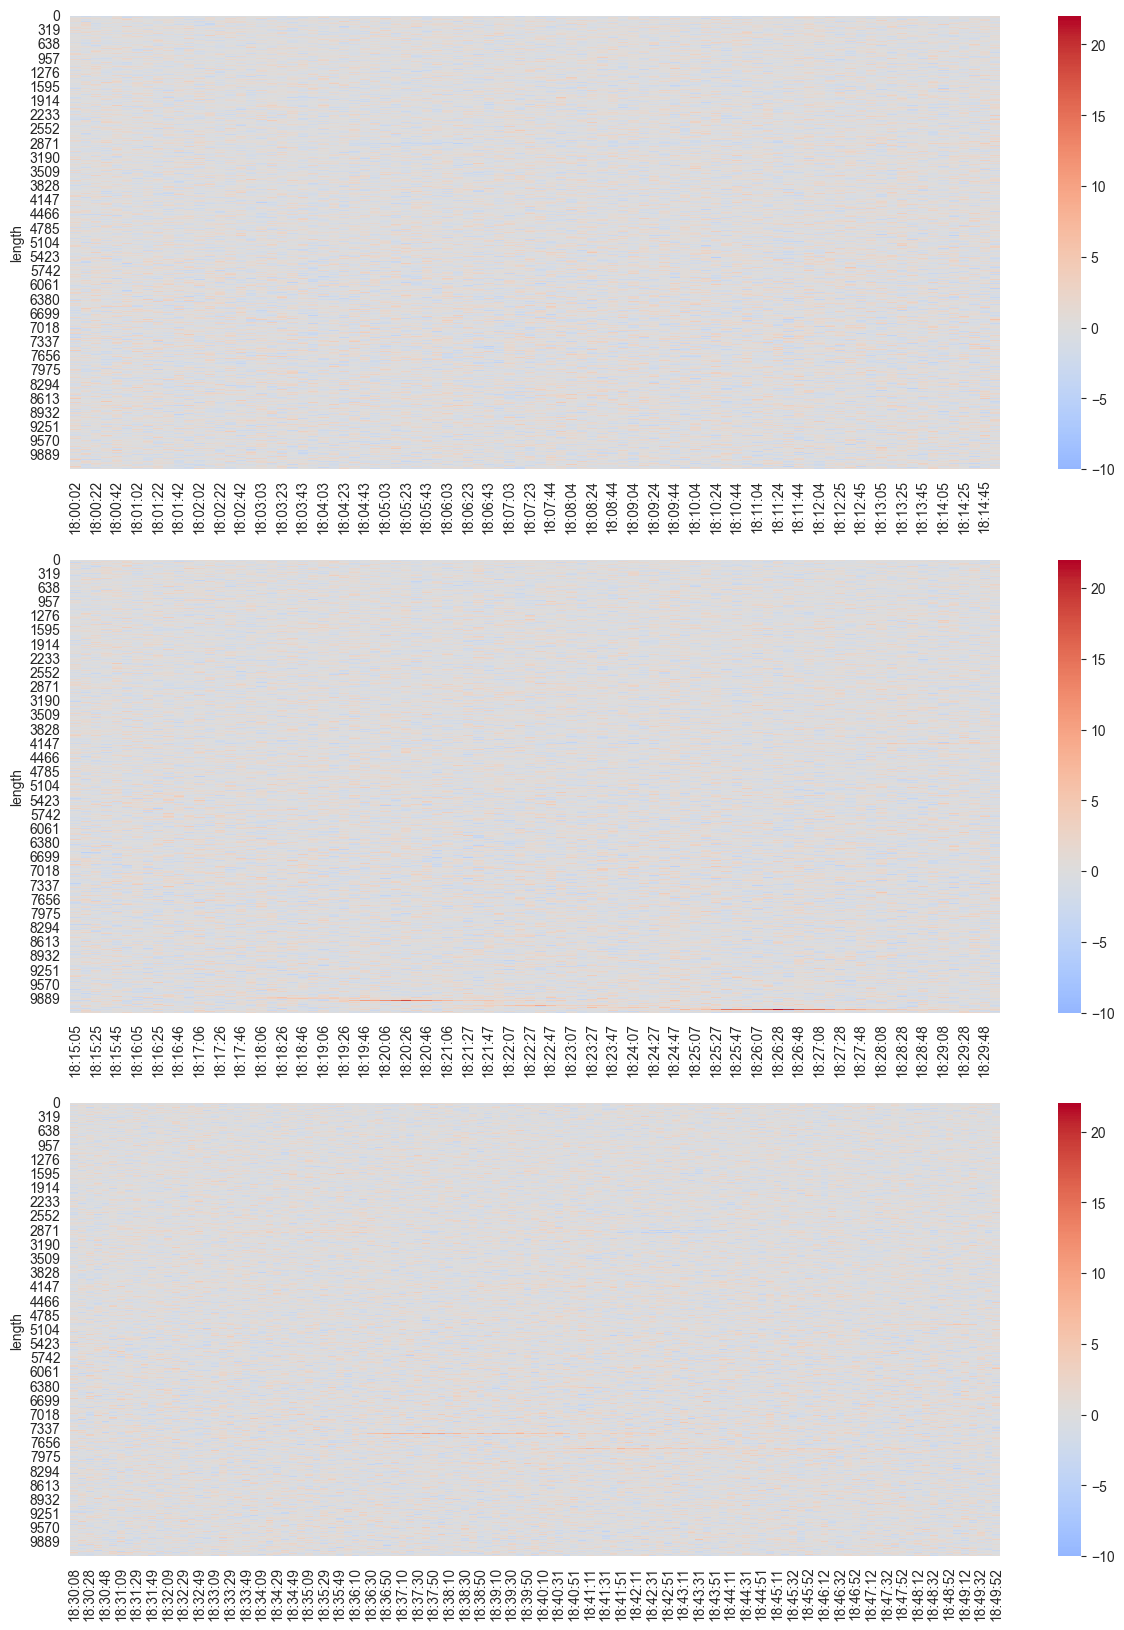

In [61]:
fig, ax = plt.subplots(3, 1, figsize=(15,20))
sns.heatmap(train_data, cmap='coolwarm', ax=ax[0], center = 0, vmin=-10, vmax=22)
sns.heatmap(val_data, cmap='coolwarm', ax=ax[1], center = 0, vmin=-10, vmax=22)
sns.heatmap(test_data, cmap='coolwarm', ax=ax[2], center = 0, vmin=-10, vmax=22)